In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0], encoding='unicode_escape')

Saving Diwali Sales Data.csv to Diwali Sales Data.csv


In [3]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [6]:
df.shape

(11251, 15)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [8]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount,Status,unnamed1
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000,0.0,0.0
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858,NaN,NaN
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869,NaN,NaN
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000,NaN,NaN
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000,NaN,NaN
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000,NaN,NaN
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000,NaN,NaN
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000,NaN,NaN


In [9]:
df.drop(['Status'], axis=1, inplace=True)

In [10]:
df.drop(['unnamed1'], axis=1, inplace=True)

In [11]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [12]:
df.dropna(inplace=True)

In [13]:
df.shape

(11239, 13)

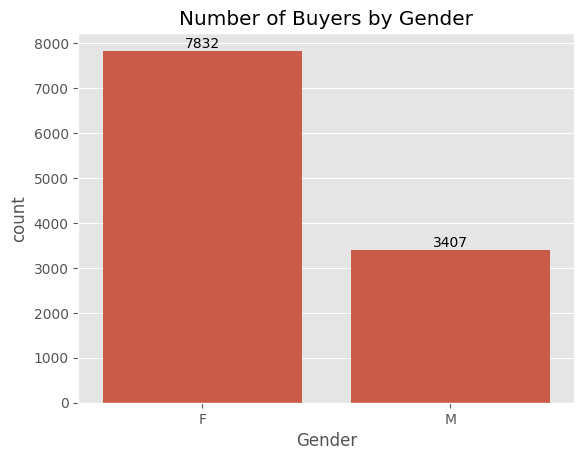

In [14]:
ax = sns.countplot(x='Gender', data=df)

for bars in ax.containers:
    ax.bar_label(bars)

plt.title("Number of Buyers by Gender")
plt.show()

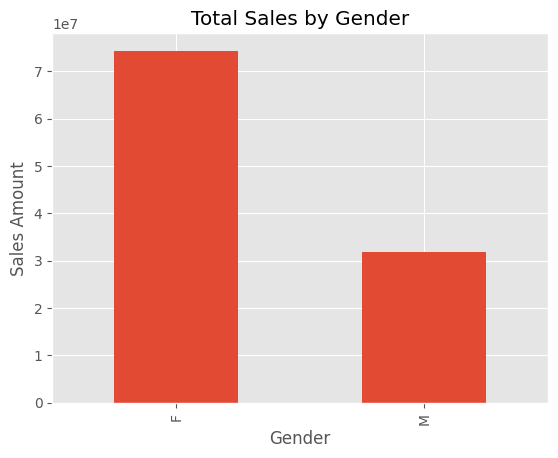

In [15]:
sales_gen = df.groupby('Gender')['Amount'].sum().sort_values(ascending=False)

sales_gen.plot(kind='bar')

plt.title("Total Sales by Gender")
plt.ylabel("Sales Amount")
plt.show()

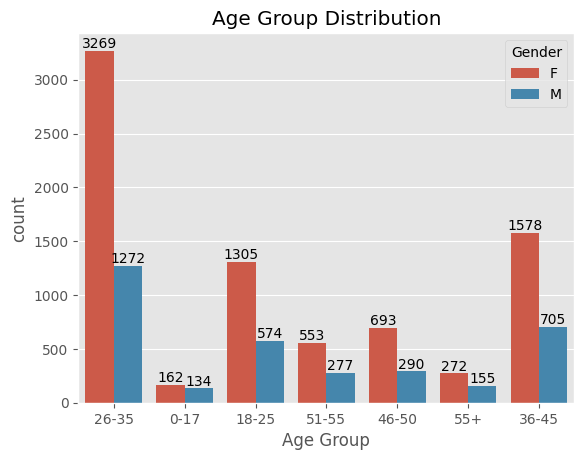

In [16]:
ax = sns.countplot(
    data=df,
    x='Age Group',
    hue='Gender'
)

for bars in ax.containers:
    ax.bar_label(bars)

plt.title("Age Group Distribution")
plt.show()

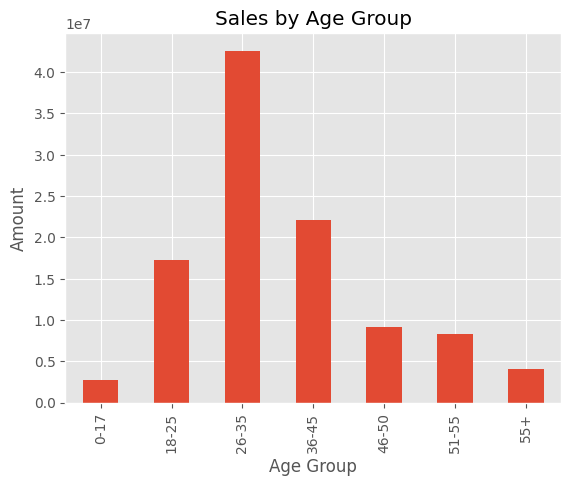

In [17]:
sales_age = df.groupby('Age Group')['Amount'].sum()

sales_age.plot(kind='bar')

plt.title("Sales by Age Group")
plt.ylabel("Amount")
plt.show()

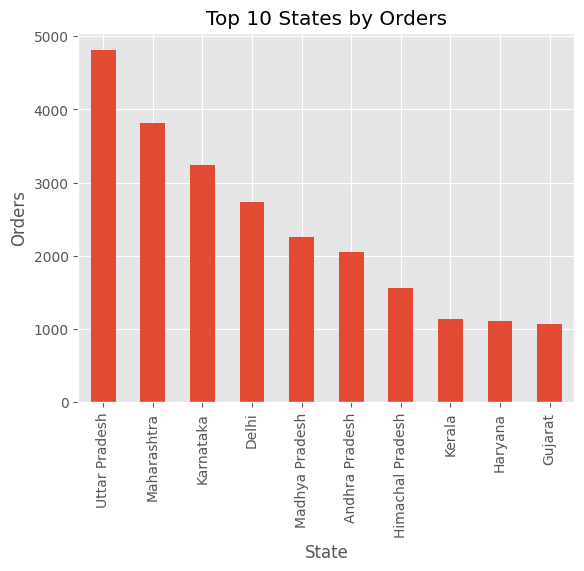

In [18]:
sales_state = (
    df.groupby('State')['Orders']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

sales_state.plot(kind='bar')

plt.title("Top 10 States by Orders")
plt.ylabel("Orders")
plt.show()

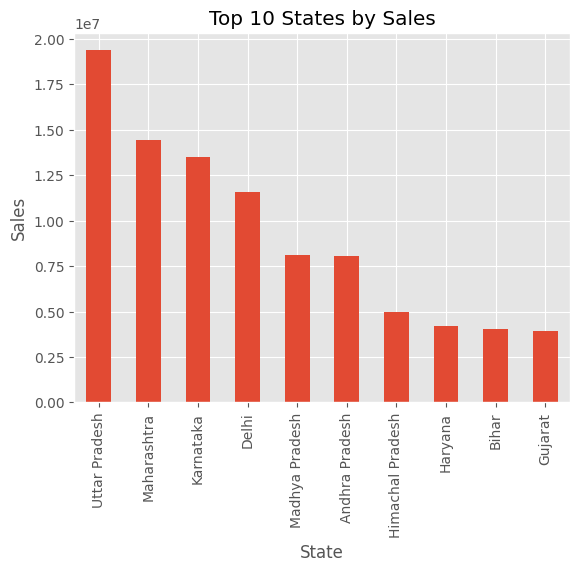

In [19]:
state_sales = (
    df.groupby('State')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

state_sales.plot(kind='bar')

plt.title("Top 10 States by Sales")
plt.ylabel("Sales")
plt.show()

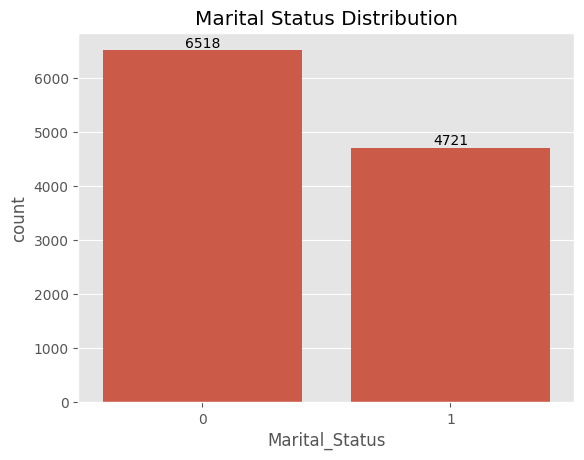

In [20]:
ax = sns.countplot(
    x='Marital_Status',
    data=df
)

for bars in ax.containers:
    ax.bar_label(bars)

plt.title("Marital Status Distribution")
plt.show()

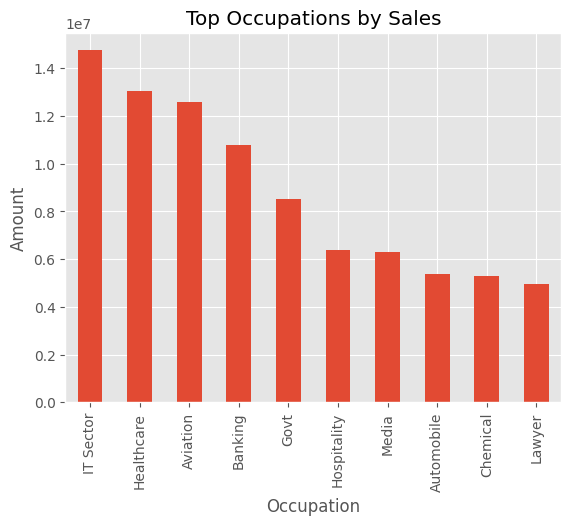

In [22]:
occupation_sales = (
    df.groupby('Occupation')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

occupation_sales.plot(kind='bar')

plt.title("Top Occupations by Sales")
plt.ylabel("Amount")
plt.show()

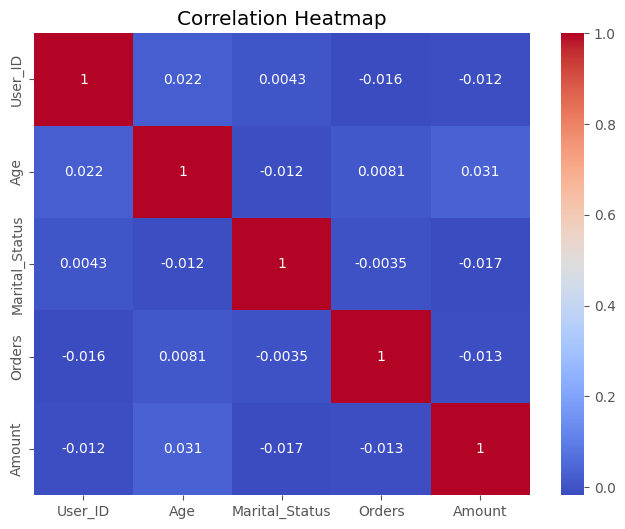

In [23]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

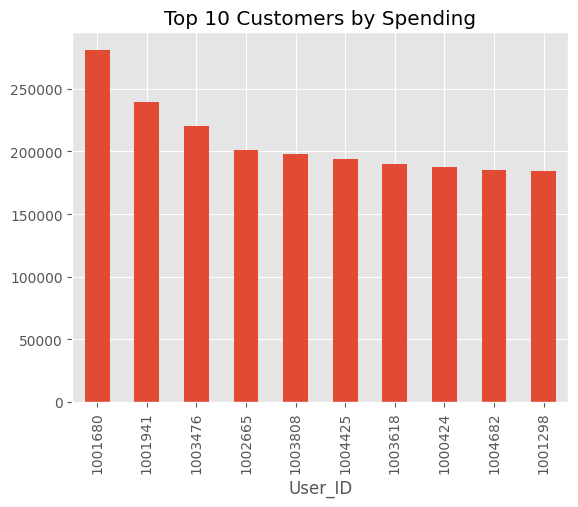

In [24]:
top_customers = (
    df.groupby('User_ID')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers.plot(kind='bar')
plt.title("Top 10 Customers by Spending")
plt.show()

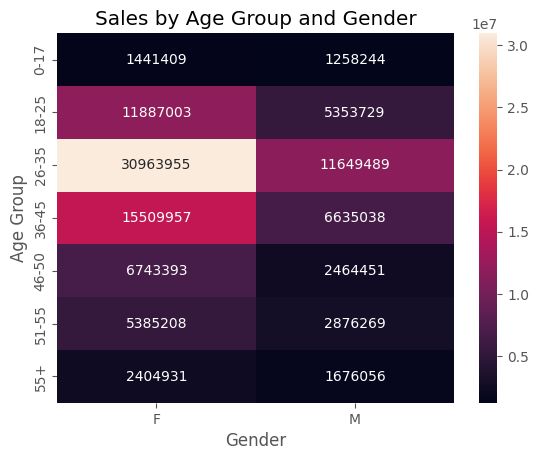

In [25]:
persona = pd.pivot_table(
    df,
    values='Amount',
    index='Age Group',
    columns='Gender',
    aggfunc='sum'
)

sns.heatmap(persona, annot=True, fmt='.0f')
plt.title("Sales by Age Group and Gender")
plt.show()

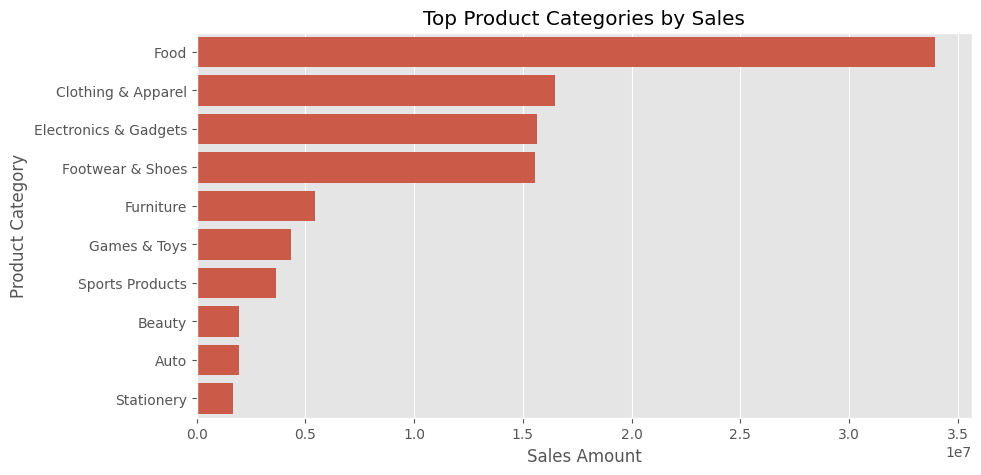

In [26]:
category_sales = (
    df.groupby('Product_Category')['Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Top Product Categories by Sales")
plt.xlabel("Sales Amount")
plt.ylabel("Product Category")
plt.show()

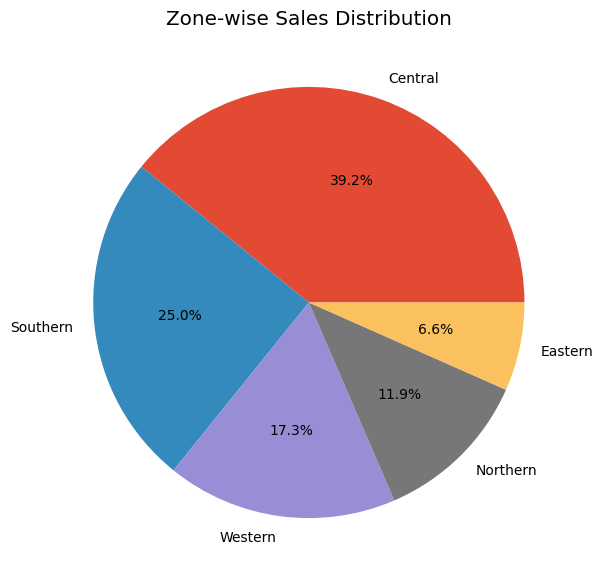

In [27]:
zone_sales = (
    df.groupby('Zone')['Amount']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7,7))

plt.pie(
    zone_sales,
    labels=zone_sales.index,
    autopct='%1.1f%%'
)

plt.title("Zone-wise Sales Distribution")
plt.show()

In [28]:
print("BUSINESS INSIGHTS")
print("- Female customers generated more revenue than male customers.")
print("- Customers aged 26-35 were the highest spending group.")
print("- Maharashtra and Uttar Pradesh contributed the highest sales.")
print("- Married customers showed stronger purchasing behavior.")
print("- Healthcare and IT professionals were among the highest spenders.")
print("- The Western Zone generated the highest revenue.")
print("- Product Category X was the best-selling category.")

BUSINESS INSIGHTS
- Female customers generated more revenue than male customers.
- Customers aged 26-35 were the highest spending group.
- Maharashtra and Uttar Pradesh contributed the highest sales.
- Married customers showed stronger purchasing behavior.
- Healthcare and IT professionals were among the highest spenders.
- The Western Zone generated the highest revenue.
- Product Category X was the best-selling category.


Key Findings
Female customers contributed the majority of Diwali sales revenue.
The 26–35 age group was the primary customer segment.
Western India generated the highest sales volume.
Certain occupations showed significantly higher spending patterns.
A small group of customers accounted for a large share of revenue.
Business Recommendations
Increase marketing efforts toward females aged 26–35.
Focus inventory on the highest-performing product categories.
Allocate more advertising budget to top-performing states.
Create loyalty programs for high-value customers.
Run targeted campaigns for high-spending occupations.